# 📈 Arrays Dinámicos

![Array Dinámico](https://cdn-icons-png.flaticon.com/256/8384/8384982.png)

[Dinámica iconos creados por Freepik - Flaticon](https://www.flaticon.es/iconos-gratis/dinamica)

## Programación III - Lic. en Sistemas

---

### 🎯 **Objetivos de Aprendizaje**

Al finalizar esta sección, podrás:

- 🔍 **Comprender** cómo funcionan los arrays dinámicos internamente
- 📊 **Analizar** el crecimiento amortizado y su complejidad
- ⚙️ **Implementar** un dynamic array desde cero
- 🎯 **Optimizar** operaciones usando conocimiento de la implementación
- 💡 **Aplicar** conceptos de amortized analysis en otros algoritmos

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/prog3-ls-fcad-uner/blob/main/cap05/03_DynamicArrays_Teoria.ipynb)

## 🌟 **¿Qué son los Dynamic Arrays?**

### 🏠 **Analogía del Mundo Real**

Imagina que tienes un **garaje** para guardar cajas:

- 📦 **Al principio**: Garaje pequeño con espacio para 4 cajas
- 📦📦📦📦 **Se llena**: Necesitas más espacio
- 🏗️ **Expansión**: Construyes un garaje 2x más grande
- 📦📦📦📦📦📦📦📦 **Trasladas todo**: Mueves las cajas al nuevo garaje
- ✅ **Ahora tienes espacio** para seguir agregando

**¿Es costoso? Sí, pero no siempre. ¿Vale la pena? ¡Absolutamente!**

![Dynamic Array Growth](https://upload.wikimedia.org/wikipedia/commons/3/31/Dynamic_array.svg)

*Fuente: Wikipedia - Dynamic Array*

### 🔬 Definición Técnica

Un **Dynamic Array** es una estructura que:

- ✅ **Crece automáticamente** cuando se queda sin espacio
- ✅ **Mantiene elementos contiguos** en memoria
- ✅ **Duplica la capacidad** cuando es necesario (estrategia común)
- ✅ **Amortiza el costo** de expansión a lo largo del tiempo
- ✅ **Proporciona acceso O(1)** por índice

![figure-5.11.png](images/figure-5.11.png)

*Figura: Un array de 12 bytes alojado en las direcciones de memoria 2146 a 2157.*

**Conceptos clave:**
- **Capacidad**: Espacio total reservado
- **Tamaño**: Elementos actuales en uso
- **Factor de crecimiento**: Multiplicador para nueva capacidad (ej: 2x)

In [4]:
# 🧪 Observando el comportamiento de Python lists

import sys

def mostrar_capacidad_list():
    """Muestra cómo crece una Python list internamente"""
    lista = []
    capacidad_anterior = 0
    
    print("📊 Crecimiento de una Python list:")
    print("Elementos | Memoria (bytes) | Capacidad estimada | Factor")
    print("-" * 60)
    
    for i in range(20):
        lista.append(i)
        memoria_actual = sys.getsizeof(lista)
        
        # Estimar capacidad (aproximada)
        overhead = 64  # Overhead básico de la list
        capacidad_estimada = (memoria_actual - overhead) // 8  # 8 bytes por referencia
        
        # Detectar crecimiento
        if capacidad_estimada > capacidad_anterior:
            factor = capacidad_estimada / capacidad_anterior if capacidad_anterior > 0 else "inicial"
            factor_str = f"{factor:.1f}x" if isinstance(factor, float) else str(factor)
            print(f"{len(lista):9} | {memoria_actual:15} | {capacidad_estimada:18} | {factor_str}")
            capacidad_anterior = capacidad_estimada

mostrar_capacidad_list()

📊 Crecimiento de una Python list:
Elementos | Memoria (bytes) | Capacidad estimada | Factor
------------------------------------------------------------
        1 |              88 |                  3 | inicial
        5 |             120 |                  7 | 2.3x
        9 |             184 |                 15 | 2.1x
       17 |             248 |                 23 | 1.5x


## 🏗️ Implementación de Dynamic Array

### 🛠️ Construyamos uno desde cero

Aunque la clase de `list` de Python proporciona una implementación altamente optimizada de matrices dinámicas, es instructivo ver cómo se podría implementar una clase de este tipo.

La clave es proporcionar medios para hacer crecer el array `A` que almacena los elementos de una lista. Por supuesto, en realidad no podemos hacer crecer ese array, ya que su capacidad es fija. Si se agrega un elemento a una lista en un momento en que el array subyacente está lleno, realizamos los siguientes pasos:

1. Asigne un nuevo array `B` con mayor capacidad.
2. Establezca `B[i] = A[i]`, para `i = 0,. . . , n −1`, donde `n` denota el número actual de artículos.
3. Establezca `A = B`, es decir, de ahora en adelante usaremos `B` como el array que respalda la lista.
4. Inserte el nuevo elemento en el nuevo array.

En las siguientes figuras se muestran los tres pasos de "crecimiento" de un array dinámico: 


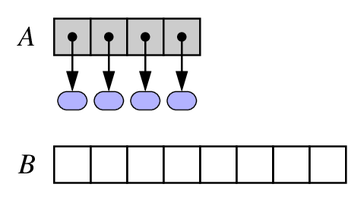

(a) crear un nuevo array B;

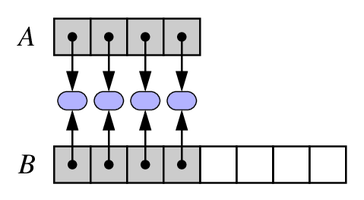

(b) almacenar los elementos de A en B;

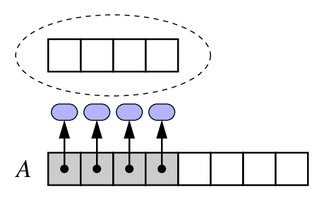

(c) reasignar la referencia A al nuevo array.

Los pasos se cierran con la futura recolección de basura del antiguo array, o la inserción del nuevo elemento en el nuevo array.

Vamos a implementar un dynamic array para entender completamente su funcionamiento.


In [ ]:
# 🧱 Implementación básica de Dynamic Array

import ctypes

class DynamicArray:
    """Implementación educativa de un Dynamic Array"""
    
    def __init__(self):
        """Inicializa un array dinámico vacío"""
        self._n = 0  # Número de elementos actuales
        self._capacity = 1  # Capacidad inicial
        self._A = self._make_array(self._capacity)  # Array interno
        
        # Estadísticas para análisis
        self._resizes = 0  # Contador de redimensionamientos
        self._total_copies = 0  # Total de elementos copiados
    
    def _make_array(self, capacity):
        """Crea un array de capacidad dada usando ctypes"""
        return (capacity * ctypes.py_object)()
    
    def __len__(self):
        """Retorna el número de elementos"""
        return self._n
    
    def __getitem__(self, index):
        """Acceso por índice"""
        if not 0 <= index < self._n:
            raise IndexError('índice fuera de rango')
        return self._A[index]
    
    def append(self, obj):
        """Agrega elemento al final"""
        if self._n == self._capacity:  # ¿Sin espacio?
            self._resize(2 * self._capacity)  # ¡Duplicar capacidad!
        
        self._A[self._n] = obj
        self._n += 1
    
    def _resize(self, new_capacity):
        """Redimensiona el array interno"""
        print(f"🔄 Redimensionando: {self._capacity} → {new_capacity}")
        
        # Crear nuevo array
        B = self._make_array(new_capacity)
        
        # Copiar elementos existentes
        for k in range(self._n):
            B[k] = self._A[k]
        
        # Actualizar referencias
        self._A = B
        self._capacity = new_capacity
        
        # Estadísticas
        self._resizes += 1
        self._total_copies += self._n
    
    def get_stats(self):
        """Retorna estadísticas de rendimiento"""
        return {
            'elementos': self._n,
            'capacidad': self._capacity,
            'factor_uso': self._n / self._capacity,
            'redimensionamientos': self._resizes,
            'copias_totales': self._total_copies,
            'copias_por_elemento': self._total_copies / self._n if self._n > 0 else 0
        }
    
    def __str__(self):
        """Representación como string"""
        return '[' + ', '.join(str(self._A[i]) for i in range(self._n)) + ']'

# Prueba inicial
print("🧱 Creando Dynamic Array...")
darr = DynamicArray()
print(f"Estado inicial: {darr.get_stats()}")

In [ ]:
# 🧪 Probando nuestro Dynamic Array

print("📊 Agregando elementos y observando redimensionamientos:")
print()

# Agregar elementos y ver el crecimiento
for i in range(10):
    darr.append(f"elemento_{i}")
    stats = darr.get_stats()
    print(f"Después de agregar {i+1:2}: {stats['elementos']} elementos, capacidad {stats['capacidad']}")

print(f"\n📈 Array final: {darr}")
print(f"\n📊 Estadísticas finales:")
final_stats = darr.get_stats()
for key, value in final_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

## 📊 Análisis Amortizado

### 🧮 ¿Por qué append() es O(1) amortizado?

Aunque **algunas** operaciones append() son costosas (cuando hay que redimensionar), la **mayoría** son baratas. El análisis amortizado distribuye el costo total entre todas las operaciones.

### 🎯 Método de análisis: Accounting Method

In [ ]:
# 🧮 Simulación de análisis amortizado

def analizar_costos_append(n_operaciones):
    """Analiza los costos de n operaciones append"""
    
    # Simular crecimiento de capacidad
    capacidad = 1
    elementos = 0
    
    costos = []  # Costo de cada operación
    redimensionamientos = []
    
    for i in range(n_operaciones):
        # ¿Necesitamos redimensionar?
        if elementos == capacidad:
            # Costo = copiar elementos + insertar nuevo
            costo = elementos + 1  # O(n) + O(1)
            capacidad *= 2
            redimensionamientos.append(i)
        else:
            # Solo insertar
            costo = 1  # O(1)
        
        costos.append(costo)
        elementos += 1
    
    return costos, redimensionamientos

# Analizar 20 operaciones
costos, redims = analizar_costos_append(20)

print("📊 Análisis de costos de append():")
print("Op# | Costo | ¿Redimensión?")
print("-" * 25)

for i, costo in enumerate(costos):
    redim = "✅ SÍ" if i in redims else "❌ No"
    print(f"{i+1:2}  | {costo:4}  | {redim}")

print(f"\n📈 Estadísticas:")
print(f"Costo total: {sum(costos)}")
print(f"Costo promedio: {sum(costos) / len(costos):.2f}")
print(f"Redimensionamientos: {len(redims)}")
print(f"\n💡 El costo promedio es O(1) ¡amortizado!")

### 🎯 Demostración Matemática

**Teorema:** El costo amortizado de append() en un dynamic array es O(1).

**Prueba:**

- Cada redimensionamiento copia n elementos
- Los redimensionamientos ocurren en posiciones: 1, 2, 4, 8, 16, ...
- Total de copias para n elementos: 1 + 2 + 4 + ... + n ≤ 2n
- Costo amortizado: 2n/n = 2 = O(1)

In [ ]:
# 🧮 Verificación empírica del teorema

def verificar_amortizacion(tamaños):
    """Verifica empíricamente que el costo es O(1) amortizado"""
    
    resultados = []
    
    for n in tamaños:
        costos, _ = analizar_costos_append(n)
        costo_total = sum(costos)
        costo_amortizado = costo_total / n
        
        resultados.append({
            'n': n,
            'costo_total': costo_total,
            'costo_amortizado': costo_amortizado
        })
    
    return resultados

# Probar con diferentes tamaños
tamaños = [10, 50, 100, 500, 1000]
resultados = verificar_amortizacion(tamaños)

print("📊 Verificación empírica de amortización:")
print("n     | Costo Total | Costo Amortizado")
print("-" * 40)

for r in resultados:
    print(f"{r['n']:4} | {r['costo_total']:10} | {r['costo_amortizado']:14.2f}")

print("\n💡 Observa: El costo amortizado se mantiene aproximadamente constante")
print("   esto confirma que es O(1) amortizado!")

## 🎛️ Factores de Crecimiento

### 🤔 ¿Por qué duplicar? ¿Y si usamos otros factores?

El factor de crecimiento afecta:

- **Memoria desperdiciada** (capacidad no usada)
- **Frecuencia de redimensionamientos**
- **Costo amortizado**

In [ ]:
# 🧪 Comparando diferentes factores de crecimiento

def simular_factor_crecimiento(n_elementos, factor):
    """Simula dynamic array con factor de crecimiento específico"""
    capacidad = 1
    elementos = 0
    redimensionamientos = 0
    copias_totales = 0
    
    capacidades = [capacidad]  # Para tracking
    
    for i in range(n_elementos):
        if elementos == capacidad:
            # Redimensionar
            nueva_capacidad = max(int(capacidad * factor), capacidad + 1)
            copias_totales += elementos
            redimensionamientos += 1
            capacidad = nueva_capacidad
            capacidades.append(capacidad)
        
        elementos += 1
    
    desperdicio = capacidad - elementos
    factor_uso = elementos / capacidad
    
    return {
        'redimensionamientos': redimensionamientos,
        'copias_totales': copias_totales,
        'capacidad_final': capacidad,
        'desperdicio': desperdicio,
        'factor_uso': factor_uso,
        'copias_por_elemento': copias_totales / n_elementos,
        'capacidades': capacidades
    }

# Comparar diferentes factores
factores = [1.5, 2.0, 2.5, 3.0]
n = 100

print(f"🔬 Comparación de factores de crecimiento (n={n}):")
print("Factor | Redim | Copias | Uso% | Copias/elem")
print("-" * 45)

for factor in factores:
    stats = simular_factor_crecimiento(n, factor)
    print(f"{factor:5.1f} | {stats['redimensionamientos']:4} | "
          f"{stats['copias_totales']:5} | {stats['factor_uso']*100:4.1f} | "
          f"{stats['copias_por_elemento']:8.2f}")

print("\n🎯 Trade-offs:")
print("📈 Factor mayor → Menos redimensionamientos, más desperdicio")
print("📉 Factor menor → Más redimensionamientos, menos desperdicio")
print("⚖️ Factor 2.0 → Buen balance (usado por Python)")

### 🤔 Mini-Quiz: Factores de Crecimiento

**Pregunta:** Si usas un factor de crecimiento de 1.1 (crecer 10%), ¿qué problemas podrías tener?

🤔 **Piensa en frecuencia de redimensionamientos...**

In [ ]:
# 🖊️ Tu código aquí - Analiza factor 1.1

# Simula factor de crecimiento muy pequeño
stats_malo = simular_factor_crecimiento(100, 1.1)
stats_bueno = simular_factor_crecimiento(100, 2.0)

print("📊 Comparación Factor 1.1 vs 2.0:")
print(f"Factor 1.1: {stats_malo['redimensionamientos']} redimensionamientos")
print(f"Factor 2.0: {stats_bueno['redimensionamientos']} redimensionamientos")

# ¿Por qué factor 1.1 es problemático?
print("\n🔍 Análisis:")
# Tu análisis aquí

## 🔄 Operaciones Adicionales

### 🗑️ Eliminación de elementos

Los dynamic arrays también pueden **decrecer** cuando se eliminan muchos elementos.

In [ ]:
# 🔧 Extendiendo nuestro Dynamic Array con eliminación

class DynamicArrayAdvanced(DynamicArray):
    """Dynamic Array con operaciones de eliminación"""
    
    def pop(self):
        """Elimina y retorna el último elemento"""
        if self._n == 0:
            raise IndexError('pop from empty array')
        
        obj = self._A[self._n - 1]
        self._A[self._n - 1] = None  # Ayuda al garbage collector
        self._n -= 1
        
        # ¿Shrink si está muy vacío?
        if self._n > 0 and self._n == self._capacity // 4:
            self._resize(self._capacity // 2)
        
        return obj
    
    def insert(self, index, obj):
        """Inserta elemento en posición específica"""
        if not 0 <= index <= self._n:
            raise IndexError('índice fuera de rango')
        
        if self._n == self._capacity:
            self._resize(2 * self._capacity)
        
        # Desplazar elementos hacia la derecha
        for j in range(self._n, index, -1):
            self._A[j] = self._A[j-1]
        
        self._A[index] = obj
        self._n += 1
    
    def remove(self, obj):
        """Elimina la primera ocurrencia del objeto"""
        for k in range(self._n):
            if self._A[k] == obj:
                # Desplazar elementos hacia la izquierda
                for j in range(k, self._n - 1):
                    self._A[j] = self._A[j+1]
                
                self._A[self._n - 1] = None
                self._n -= 1
                
                # ¿Shrink?
                if self._n > 0 and self._n == self._capacity // 4:
                    self._resize(self._capacity // 2)
                
                return
        
        raise ValueError(f'{obj} not in array')

# Probar funcionalidad extendida
print("🔧 Probando Dynamic Array Avanzado:")
darr_adv = DynamicArrayAdvanced()

# Llenar array
for i in range(8):
    darr_adv.append(f"item_{i}")

print(f"Array lleno: {darr_adv}")
print(f"Stats: {darr_adv.get_stats()}")

# Eliminar elementos
print("\n🗑️ Eliminando elementos...")
for _ in range(6):
    removed = darr_adv.pop()
    stats = darr_adv.get_stats()
    print(f"Eliminado {removed}, capacidad: {stats['capacidad']}")

print(f"\nArray final: {darr_adv}")

## 🏋️ Ejercicio Práctico

### 📝 Problema: Buffer de Streaming

Implementa un buffer para streaming de datos que use dynamic arrays eficientemente.

In [ ]:
# 🖊️ Tu código aquí - Buffer de Streaming

import time
import random

class StreamingBuffer:
    """Buffer eficiente para datos de streaming usando dynamic array"""
    
    def __init__(self, max_size=1000):
        """Inicializa buffer con tamaño máximo"""
        # Tu código aquí:
        # 1. Usar DynamicArrayAdvanced como buffer interno
        # 2. Configurar tamaño máximo
        # 3. Tracking de estadísticas (datos recibidos, procesados, etc.)
        pass
    
    def receive_data(self, data):
        """Recibe nuevo dato del stream"""
        # Tu código aquí:
        # 1. Agregar dato al buffer
        # 2. Si excede max_size, eliminar los más viejos (FIFO)
        # 3. Actualizar estadísticas
        pass
    
    def process_batch(self, batch_size=10):
        """Procesa un lote de datos del buffer"""
        # Tu código aquí:
        # 1. Extraer hasta batch_size elementos del inicio
        # 2. Simular procesamiento
        # 3. Retornar elementos procesados
        pass
    
    def get_status(self):
        """Retorna estado actual del buffer"""
        # Tu código aquí:
        # 1. Tamaño actual del buffer
        # 2. Estadísticas de capacidad
        # 3. Métricas de throughput
        pass
    
    def simulate_streaming(self, duration_seconds=5):
        """Simula streaming de datos por un tiempo determinado"""
        # Tu código aquí:
        # 1. Simular llegada aleatoria de datos
        # 2. Procesamiento periódico en lotes
        # 3. Monitorear rendimiento del dynamic array
        pass

# Prueba tu implementación
print("📡 Probando Buffer de Streaming...")
buffer = StreamingBuffer(max_size=50)

# Simular streaming
buffer.simulate_streaming(duration_seconds=2)

print("\n📊 Análisis de rendimiento:")
print("- ¿Cuántos redimensionamientos ocurrieron?")
print("- ¿Fue eficiente el uso de memoria?")
print("- ¿El costo fue realmente amortizado?")

## 🌐 Dynamic Arrays en el Mundo Real

### 🎯 Aplicaciones Comunes

**Python Lists:**

- 🐍 Implementación nativa de dynamic arrays
- 📈 Factor de crecimiento ~1.125 (más conservador que 2x)
- 🔧 Optimizaciones especiales para casos comunes

**Otros lenguajes:**

- ☕ Java ArrayList
- 🔷 C++ std::vector  
- 🟨 JavaScript Array
- 🦀 Rust Vec

**Casos de uso:**

- 📊 **Buffers de datos** dinámicos
- 🎮 **Game engines** (entidades, objetos)
- 🌐 **Web servers** (conexiones activas)
- 📱 **Apps móviles** (listas de contenido)
- 🤖 **Machine Learning** (datasets, batch processing)

In [ ]:
# 🧪 Comparando con Python list real

import timeit
import sys

def benchmark_append(implementacion, n_elementos):
    """Benchmark de operaciones append"""
    
    if implementacion == 'python_list':
        def test():
            lista = []
            for i in range(n_elementos):
                lista.append(i)
            return lista
    
    elif implementacion == 'our_dynamic_array':
        def test():
            darr = DynamicArray()
            for i in range(n_elementos):
                darr.append(i)
            return darr
    
    # Medir tiempo
    tiempo = timeit.timeit(test, number=1)
    resultado = test()
    
    return tiempo, resultado

# Comparar implementaciones
n = 1000
print(f"🏁 Benchmark: {n} operaciones append")
print("-" * 40)

# Python list nativa
tiempo_py, lista_py = benchmark_append('python_list', n)
print(f"Python list:     {tiempo_py:.4f} segundos")

# Nuestra implementación
tiempo_our, darr_our = benchmark_append('our_dynamic_array', n)
print(f"Our DynamicArray: {tiempo_our:.4f} segundos")

# Comparación
factor = tiempo_our / tiempo_py
print(f"\n📊 Python list es {factor:.1f}x más rápida")
print("💡 Esto es normal - Python está optimizado en C!")

# Verificar que ambas funcionan igual
print(f"\n✅ Ambas implementaciones producen el mismo resultado: {len(lista_py) == len(darr_our)}")

## 🎯 Resumen y Conceptos Clave

### ✅ Lo que aprendimos

1. 📈 Dynamic Arrays crecen automáticamente
   - Duplican capacidad cuando se llenan
   - Mantienen elementos en memoria contigua
   - Proporcionan acceso O(1) por índice

2. 🧮 Análisis amortizado
   - append() es O(1) amortizado, no O(1) worst-case
   - El costo de redimensionamiento se distribuye
   - Total de copias ≤ 2n para n elementos

3. 🎛️ Factor de crecimiento importa
   - Factor 2.0: Buen balance general
   - Factor mayor: Menos redimensionamientos, más desperdicio
   - Factor menor: Más redimensionamientos, menos desperdicio

4. 🔄 Operaciones adicionales
   - insert(): O(n) por desplazamiento
   - remove(): O(n) por búsqueda y desplazamiento
   - pop(): O(1) amortizado

5. 🌐 Aplicaciones reales
   - Base de Python lists, Java ArrayList, C++ vector
   - Esencial en sistemas de buffer y streaming
   - Trade-off memoria vs tiempo bien definido

### 🔄 Próximo paso:
**⚡ Efficiency Analysis** - Comparando complejidades de todas las operaciones

---

### 🤔 Preguntas de Reflexión:

1. ¿Por qué el análisis amortizado es más realista que worst-case para dynamic arrays?
2. ¿En qué aplicaciones sería problemático el comportamiento O(n) ocasional?
3. ¿Cómo optimizarías un dynamic array para un caso de uso específico?

**💡 Piensa en el balance entre simplicidad y eficiencia!**

---

## 📚 Referencias Bibliográficas

### 📖 **Fuente Principal:**
- **Goodrich, M. T., Tamassia, R., & Goldwasser, M. H.** (2013). *Data Structures and Algorithms in Python*. John Wiley & Sons. **Capítulo 5: Array-Based Sequences** (pp. 179-226).

### 📘 **Referencias Complementarias:**
- **Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C.** (2009). *Introduction to Algorithms* (3rd ed.). MIT Press. **Capítulo 17: Amortized Analysis**.
- **Sedgewick, R., & Wayne, K.** (2011). *Algorithms* (4th ed.). Addison-Wesley. **Capítulo 1.4: Analysis of Algorithms**.
- **Python Software Foundation** (2025). *Python Documentation - list*. <https://docs.python.org/3/library/stdtypes.html#list>

### 🔗 **Recursos Online:**
- **MIT OpenCourseWare** (2025). *Introduction to Algorithms - Amortized Analysis*. <https://ocw.mit.edu/>
- **GeeksforGeeks** (2025). *Dynamic Array Implementation*. <https://www.geeksforgeeks.org/dynamic-array/>

---

![Creative Commons](https://mirrors.creativecommons.org/presskit/buttons/80x15/png/by-sa.png)

© 2025 Cátedra Programación III – Lic. Sistemas – FCAD/UNER

This notebook is licensed under a Creative Commons Attribution-ShareAlike 4.0 International License (CC BY-SA 4.0)

<https://creativecommons.org/licenses/by-sa/4.0/>